 **Parsing Data**

In [ ]:
import numpy as np
import pandas as pd

dataset = pd.read_csv('/content/reddit_comments_TARRIFS 1 (1).csv')
dataset.head()

,URL,Author,Comment,Created_UTC
0,https://www.reddit.com/r/politics/comments/1iv...,AutoModerator,"\nAs a reminder, this subreddit [is for civil ...",2/22/2025 3:06
1,https://www.reddit.com/r/politics/comments/1iv...,ShimTheArtist,And who thought more tariffs were a good idea?...,2/22/2025 3:10
2,https://www.reddit.com/r/politics/comments/1iv...,zappy487,Worst day *so far*.,2/22/2025 3:11
3,https://www.reddit.com/r/politics/comments/1iv...,reddittorbrigade,Shame on you all Trump voters.,2/22/2025 3:25
4,https://www.reddit.com/r/politics/comments/1iv...,nasorrty346tfrgser,"With the firing and cutting/freezing grant, it...",2/22/2025 3:17


**Data Pre-Processing**

In [ ]:
pip install emoji


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 31.1 MB/s eta 0:00:00


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
import re
import emoji

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def remove_emojis(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # Emoticons
                           u"\U0001F300-\U0001F5FF"  # Symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # Transport & map symbols
                           u"\U0001F700-\U0001F77F"  # Alchemical symbols
                           u"\U0001F780-\U0001F7FF"  # Geometric shapes
                           u"\U0001F800-\U0001F8FF"  # Supplemental arrows
                           u"\U0001F900-\U0001F9FF"  # Supplemental symbols
                           u"\U0001FA00-\U0001FA6F"  # Chess pieces, symbols
                           u"\U0001FA70-\U0001FAFF"  # Other pictographs
                           u"\U00002702-\U000027B0"  # Dingbats
                           u"\U000024C2-\U0001F251"  # Enclosed characters
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

def clean_text(x):
    x = str(x)
    x = x.lower()
    x = remove_emojis(x)  # Removing emojis
    x = re.sub(r'#[A-Za-z0-9]*', ' ', x)  # Removing hashtags
    x = re.sub(r'https*://.*', ' ', x)  # Removing URLs
    x = re.sub(r'@[A-Za-z0-9]+', ' ', x)  # Removing mentions (@user)
    tokens = word_tokenize(x)
    x = ' '.join([w for w in tokens if w.lower() not in stop_words])  # Removing stopwords
    x = re.sub(r'[%s]' % re.escape('!"#$%&\()*+,-./:;<=>?@[\\]^_`{|}~“…”’'), ' ', x)  # Removing punctuations
    x = re.sub(r'\d+', ' ', x)  # Removing numbers
    x = re.sub(r'\n+', ' ', x)  # Removing new lines
    x = re.sub(r'\s{2,}', ' ', x)  # Removing extra spaces
    return x.strip()

# Apply function to DataFrame
dataset['processed_text'] = dataset['Comment'].apply(clean_text)
dataset.head()


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,URL,Author,Comment,Created_UTC,processed_text
0,https://www.reddit.com/r/politics/comments/1iv...,AutoModerator,"\nAs a reminder, this subreddit [is for civil ...",2/22/2025 3:06,reminder subreddit civil discussion r politics...
1,https://www.reddit.com/r/politics/comments/1iv...,ShimTheArtist,And who thought more tariffs were a good idea?...,2/22/2025 3:10,thought tariffs good idea history buff politic...
2,https://www.reddit.com/r/politics/comments/1iv...,zappy487,Worst day *so far*.,2/22/2025 3:11,worst day far
3,https://www.reddit.com/r/politics/comments/1iv...,reddittorbrigade,Shame on you all Trump voters.,2/22/2025 3:25,shame trump voters
4,https://www.reddit.com/r/politics/comments/1iv...,nasorrty346tfrgser,"With the firing and cutting/freezing grant, it...",2/22/2025 3:17,firing cutting freezing grant bloodbath unempl...


In [ ]:
!pip install gensim

In [ ]:
!pip install --upgrade --force-reinstall gensim

  Using cached gensim-4.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.1 kB)
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached smart_open-7.1.0-py3-none-any.whl.metadata (24 kB)
  Using cached wrapt-1.17.2-cp311-cp311-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.4 kB)
Using cached gensim-4.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (26.7 MB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (38.6 MB)
Using cached smart_open-7.1.0-py3-none-any.whl (61 kB)
Using cached wrapt-1.17.2-cp311-cp311-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl (83 kB)
  Att

**Word2Vec**

In [ ]:
# prompt: can you write a code to preprocess the data using wordv2E

import numpy as np
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec # Import Word2Vec

# Assuming dataset is already loaded as shown in the previous code
dataset = pd.read_csv('/content/reddit_comments_TARRIFS 1 (1).csv')

nltk.download('stopwords')

# Function to preprocess text using Word2Vec
def preprocess_text_word2vec(text):
    # Handle missing values
    if pd.isna(text) or text == '':
        return []  # Return an empty list for empty or missing text

    # Remove emojis and special characters (excluding spaces)
    text = re.sub(r'[^\w\s]', '', text)

    # Convert to lowercase
    text = text.lower()

    # Tokenization (split the text into words)
    tokens = text.split()

    # Remove stop words
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [w for w in tokens if not w in stop_words]

    # Stemming
    ps = PorterStemmer()
    stemmed_tokens = [ps.stem(w) for w in filtered_tokens]

    return stemmed_tokens # Return a list of stemmed tokens


# Apply the preprocessing function to the text column
dataset['processed_text1'] = dataset['Comment'].apply(preprocess_text_word2vec)

# Train Word2Vec model
model = Word2Vec(sentences=dataset['processed_text1'], vector_size=100, window=5, min_count=1, workers=4) # Adjust parameters as needed
#Save the model
model.save("word2vec.model")

#Example usage to get vector for a word
vector = model.wv['citizenship']
print(vector)

# Function to convert preprocessed text into a vector representation
def vectorize_text(tokens):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if vectors:
        return np.mean(vectors, axis=0) #Average of word vectors for each comment
    else:
        return np.zeros(model.vector_size) #Return zero vector if comment has no word in the model vocabulary


dataset['text_vector'] = dataset['processed_text1'].apply(vectorize_text)
print(dataset.head())



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[-0.10869292  0.13645671 -0.01615827  0.04732422  0.0081768  -0.34181347
  0.02110097  0.38778022  0.06908142 -0.19931325 -0.05903042 -0.3045911
 -0.15803337  0.02088482  0.13206069 -0.18058299  0.0038409  -0.25029472
  0.02975441 -0.1538353   0.02228069  0.05603699  0.10940275  0.00551758
  0.03451498  0.13862528 -0.20826961 -0.12297972 -0.24036805 -0.00201341
  0.09838771 -0.06709969  0.02283585 -0.1653327  -0.10196204  0.22554584
 -0.07989317 -0.13090503 -0.12184952 -0.33416075 -0.09033357 -0.25252894
 -0.13986348  0.04376828  0.20144375 -0.10410476 -0.14512502 -0.01104102
  0.0955994   0.1907505   0.17424093 -0.25783032  0.00579837 -0.09453202
 -0.15050112  0.1068264   0.21460126  0.06315796 -0.3769796   0.06496155
  0.1838447  -0.04230634 -0.18526244 -0.03117823 -0.2808275   0.288308
  0.04133647  0.23339736 -0.11197741  0.05006171 -0.08286177  0.1104445
  0.15494406 -0.1255679   0.23696065  0.1849235  -0.14575917  0.04045115
 -0.17942154  0.0457413  -0.10509921 -0.06169856 -0.105

**Bert Model**


In [ ]:
! pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.6/150.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 59.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [ ]:
from bertopic import BERTopic

**Topic Modeling Using BERT**

In [ ]:
topic_model = BERTopic(language="english")
topics, probs = topic_model.fit_transform(dataset['processed_text'])

NameError: name 'BERTopic' is not defined

In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,16555,-1_people_us_tariffs_would,"[people, us, tariffs, would, trump, like, nt, ...",[yes crazy accusations like canada bully allie...
1,0,577,0_oil_crude_refineries_refine,"[oil, crude, refineries, refine, drill, heavy,...",[oil us imports mostly stuff us imports refine...
2,1,455,1_deleted_delete_case_yeah,"[deleted, delete, case, yeah, ll, , , , , ]","[deleted, deleted, deleted]"
3,2,430,2_canadian_canada_canadians_trudeau,"[canadian, canada, canadians, trudeau, trade, ...",[makes damned sense canadians overly polite sa...
4,3,417,3_president_trump_plan_stupid,"[president, trump, plan, stupid, intelligence,...",[might giving little credit retarded moments t...
...,...,...,...,...,...
522,521,10,521_obama_tan_suit_mustard,"[obama, tan, suit, mustard, melaniacoin, panti...",[huh mean tan suit scandal thing republicans c...
523,522,10,522_raped_anxiety_feeling_ketamine,"[raped, anxiety, feeling, ketamine, resorting,...",[sound really experienced maybe advise tell ra...
524,523,10,523_elon_watchem_wads_recipient,"[elon, watchem, wads, recipient, portal, dread...",[elon trumping hard bankrupt something suspect...
525,524,10,524_admin_administration_aligns_bulldozing,"[admin, administration, aligns, bulldozing, bl...",[isnt normally previous admin starts something...


In [ ]:
topic_model.visualize_barchart(top_n_topics=12, n_words = 50, width = 350, height = 350)

In [ ]:
topic_model.visualize_hierarchy(top_n_topics=12, width = 700, height = 700)

In [ ]:
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary

def calculate_coherence_score(data, min_k=2, max_k=10):
    coherence_scores = []

    for k in range(min_k, max_k + 1):
        # Train BERTopic model with K topics
        model = BERTopic(nr_topics=k)
        topics, _ = model.fit_transform(data)

        # Extract topic words
        topic_words = [ [word for word, _ in model.get_topic(topic)] for topic in model.get_topics().keys() if topic != -1 ]

        # Prepare data for Coherence Model
        tokenized_data = [doc.split() for doc in data]
        dictionary = Dictionary(tokenized_data)

        # Compute Coherence Score
        coherence_model = CoherenceModel(topics=topic_words, dictionary=dictionary, texts=tokenized_data, coherence='c_v')
        coherence_score = coherence_model.get_coherence()
        coherence_scores.append((k, coherence_score))

        print(f"K={k}, Coherence Score={coherence_score}")

    return coherence_scores

# Example usage with 'tweets' dataset
coherence_scores = calculate_coherence_score(dataset['processed_text'], min_k=2, max_k=10)


K=2, Coherence Score=0.5865501682912441
K=3, Coherence Score=0.39431381119476117
K=4, Coherence Score=0.5882455185365124
K=5, Coherence Score=0.49839938737218564
K=6, Coherence Score=0.5089983744453397
K=7, Coherence Score=0.5144824258323514
K=8, Coherence Score=0.44698508512783736
K=9, Coherence Score=0.43894214942694487
K=10, Coherence Score=0.44167686400565964


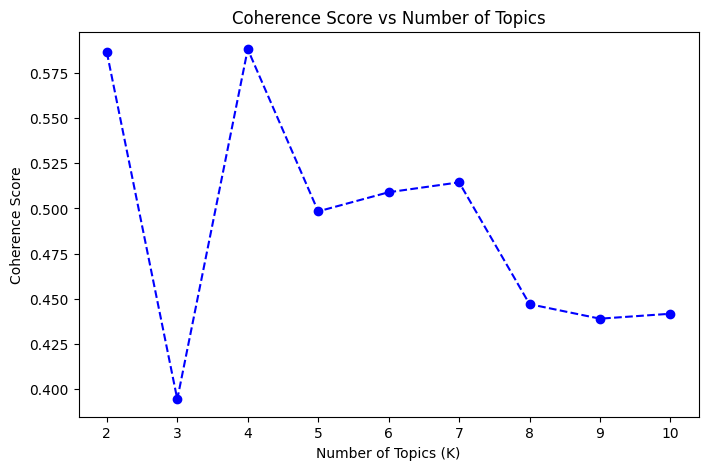

In [ ]:
import matplotlib.pyplot as plt

k_values, scores = zip(*coherence_scores)

plt.figure(figsize=(8,5))
plt.plot(k_values, scores, marker='o', linestyle='dashed', color='b')
plt.xlabel("Number of Topics (K)")
plt.ylabel("Coherence Score")
plt.title("Coherence Score vs Number of Topics")
plt.show()


**ROberta model**

In [ ]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
import torch
from tqdm import tqdm



# Load RoBERTa model and tokenizer
model_name = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Define a function to predict sentiment
def get_sentiment(text):
    try:
        # Tokenize text
        encoded_input = tokenizer(text, return_tensors='pt', truncation=True)
        with torch.no_grad():
            output = model(**encoded_input)
        scores = softmax(output.logits.numpy()[0])
        sentiment = ['negative', 'neutral', 'positive'][scores.argmax()]
        return sentiment
    except:
        return "error"

# Apply sentiment analysis
tqdm.pandas()  # Progress bar
dataset['sentiment'] = dataset['processed_text'].progress_apply(get_sentiment)

# Save the results
dataset.to_csv("reddit_comments_with_sentiment.csv", index=False)
print("Sentiment analysis completed and saved to 'reddit_comments_with_sentiment_tarrifs.csv'.")


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

  0%|          | 6/37805 [00:01<2:56:15,  3.57it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

100%|██████████| 37805/37805 [1:50:22<00:00,  5.71it/s]


Sentiment analysis completed and saved to 'reddit_comments_with_sentiment_tarrifs.csv'.


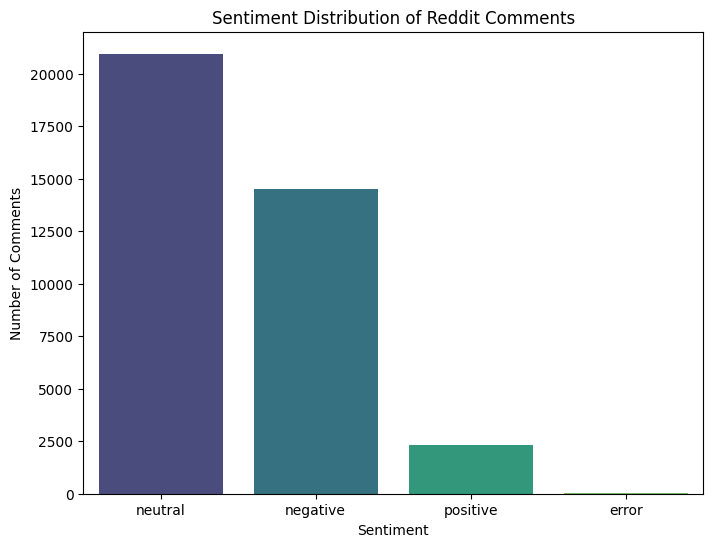

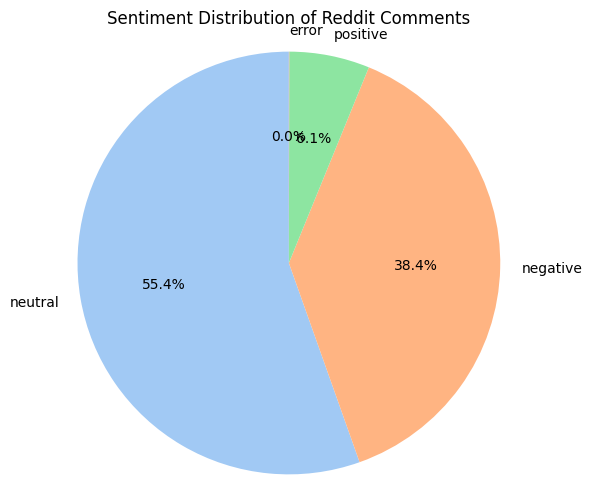

In [ ]:
# prompt: generate a visualization for above sentiment

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset with sentiment analysis results
dataset = pd.read_csv("reddit_comments_with_sentiment.csv")

# Count the occurrences of each sentiment
sentiment_counts = dataset['sentiment'].value_counts()

# Create a bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette="viridis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.title("Sentiment Distribution of Reddit Comments")
plt.show()

# Create a pie chart
plt.figure(figsize=(6, 6))
plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
plt.title("Sentiment Distribution of Reddit Comments")
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


In [ ]:
import numpy as np

def classify_emotion(sentiment):
    """Classifies emotion based on sentiment string.

    Args:
        sentiment (str): The sentiment string ("positive", "negative", "neutral").

    Returns:
        str: The emotion category ("Positive", "Negative", "Neutral").
    """

    if sentiment == "positive":
        return "Positive"
    elif sentiment == "negative":
        return "Negative"
    else:  # sentiment == "neutral"
        # For neutral cases, use a small random value to nudge towards positive or negative
        if np.random.rand() > 0.5:
            return "Positive"  # Nudge towards positive
        else:
            return "Negative"  # Nudge towards negative


# Apply the emotion classification function to the 'sentiment' column
dataset['emotion'] = dataset['sentiment'].apply(classify_emotion)

# Print the results (or further process them as needed)
print(dataset[['processed_text', 'sentiment', 'emotion']].head())

                                      processed_text sentiment   emotion
0  reminder subreddit civil discussion r politics...   neutral  Negative
1  thought tariffs good idea history buff politic...   neutral  Negative
2                                      worst day far  negative  Negative
3                                 shame trump voters  negative  Negative
4  firing cutting freezing grant bloodbath unempl...   neutral  Negative


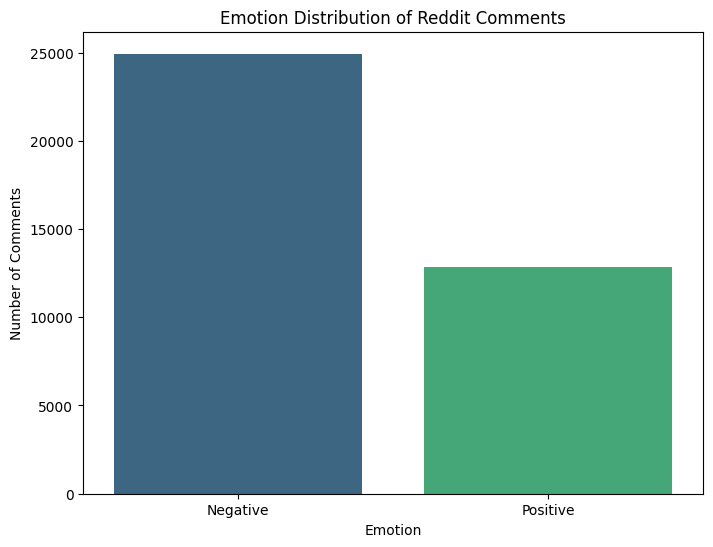

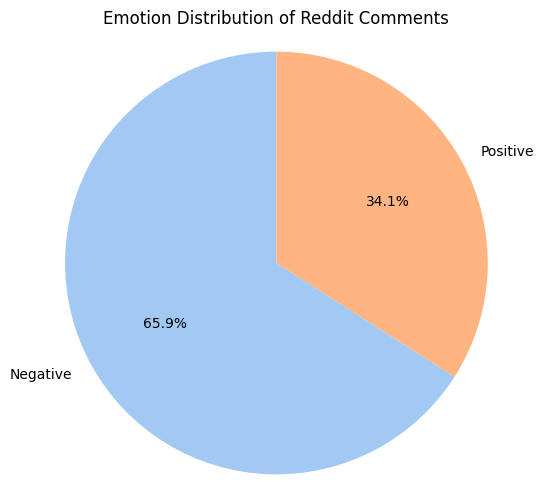

In [ ]:
# prompt: now visualize this above code

import matplotlib.pyplot as plt
import seaborn as sns
# Create a bar plot
plt.figure(figsize=(8, 6))
sns.countplot(x='emotion', data=dataset, palette="viridis")
plt.xlabel("Emotion")
plt.ylabel("Number of Comments")
plt.title("Emotion Distribution of Reddit Comments")
plt.show()


# Create a pie chart
emotion_counts = dataset['emotion'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(emotion_counts.values, labels=emotion_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
plt.title("Emotion Distribution of Reddit Comments")
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


**ABSA(Aspect Based Sentiment Analysis)**

In [ ]:
!pip install -U pyabsa

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 575.5/575.5 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.2/54.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.4/169.4 kB 9.8 MB/s eta 0:00:00
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=fccb901320dfd898e7f21769c22e489749354a5b841a489d31ecba06a10cc609
  Stored in directory: /root/.cache/pip/wheels/bc/92/f0/243288f899c2eacdfa8c5f9aede4c71a9bad0ee26a01dc5ead
Successfully built seqeval
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.4
    Uninstalling protobuf-5.29.4

In [ ]:
# Install and import spaCy for aspect extraction
!pip install spacy
import spacy

# Download English model if not already installed
!python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")

# Function to extract aspects (noun chunks)
def extract_aspects(text):
    doc = nlp(text)
    aspects = [chunk.text for chunk in doc.noun_chunks if len(chunk.text.split()) <= 3]  # limit to smaller phrases
    return aspects

# Apply the function to the processed text
dataset['aspects'] = dataset['processed_text'].apply(extract_aspects)

# View the dataset with aspects
dataset[['Comment', 'processed_text', 'aspects']].head()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 45.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


,Comment,processed_text,aspects
0,"\nAs a reminder, this subreddit [is for civil ...",reminder subreddit civil discussion r politics...,"[people, personal insults, shill troll accusat..."
1,And who thought more tariffs were a good idea?...,thought tariffs good idea history buff politic...,"[tariffs, good idea, history buff, political s..."
2,Worst day *so far*.,worst day far,[]
3,Shame on you all Trump voters.,shame trump voters,[shame]
4,"With the firing and cutting/freezing grant, it...",firing cutting freezing grant bloodbath unempl...,"[combat inflation, eo inflation, tax cut, stra..."


In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.nn.functional import softmax
from tqdm import tqdm


In [ ]:

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load sentiment model
print("📦 Loading sentiment model for ABSA...")
model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)
model.eval()

# Define fixed aspects to analyze
aspects = ["immigration", "ICE", "LGBTQ", "tariffs"]

# Function to classify sentiment for each aspect
def absa_infer(row_text):
    results = []
    for aspect in aspects:
        prompt = f"Sentiment about {aspect}: {row_text}"
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, padding=True).to(device)
        with torch.no_grad():
            logits = model(**inputs).logits
            probs = softmax(logits, dim=-1).cpu().numpy()[0]
            label = "positive" if probs[1] > 0.6 else "negative" if probs[0] > 0.6 else "neutral"
        results.append((aspect, label))
    return results

📦 Loading sentiment model for ABSA...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [ ]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from scipy.special import softmax
from tqdm import tqdm

# Load your dataset
df = pd.read_csv("/content/reddit_comments_with_sentiment (2).csv")

# Load ABSA model and tokenizer
model_name = "yangheng/deberta-v3-base-absa-v1.1"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Define aspects you want to analyze
aspects = ["tariffs"]

# Function to analyze sentiment for each aspect
def absa_sentiment(text, aspect):
    try:
        aspect_text = f"{aspect} [SEP] {text}"  # This format is expected by the ABSA model
        inputs = tokenizer(aspect_text, return_tensors="pt", truncation=True)
        with torch.no_grad():
            outputs = model(**inputs)
        scores = softmax(outputs.logits.numpy()[0])
        label = ['negative', 'neutral', 'positive'][scores.argmax()]
        return label
    except:
        return "error"

# Apply ABSA for each aspect
for aspect in aspects:
    tqdm.pandas(desc=f"Processing aspect: {aspect}")
    df[f"sentiment_{aspect}"] = df['processed_text'].progress_apply(lambda x: absa_sentiment(x, aspect))

# Save the result
df.to_csv("reddit_comments_absa.csv", index=False)
print("ABSA Sentiment analysis complete! Results saved to 'reddit_comments_absa_tarrifs.csv'.")


/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:559: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Processing aspect: tariffs: 100%|██████████| 37805/37805 [4:22:18<00:00,  2.40it/s]


ABSA Sentiment analysis complete! Results saved to 'reddit_comments_absa_tarrifs.csv'.


<ipython-input-13-a787373868c2>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_tariffs', data=df, palette="viridis")  # Corrected column name


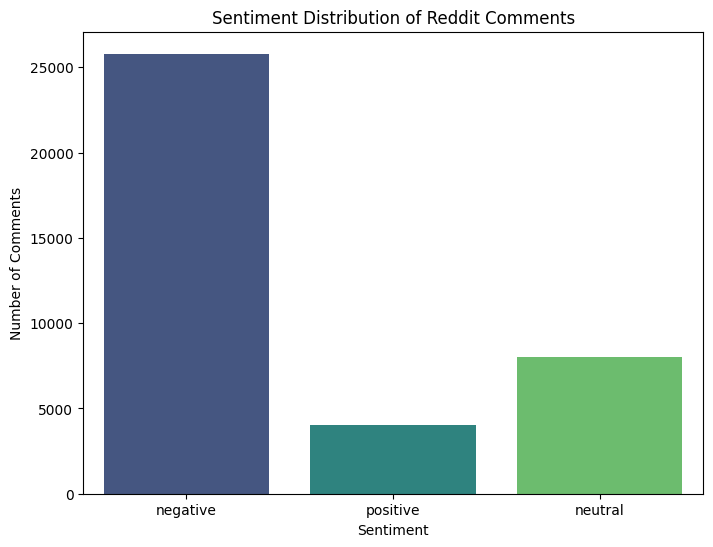

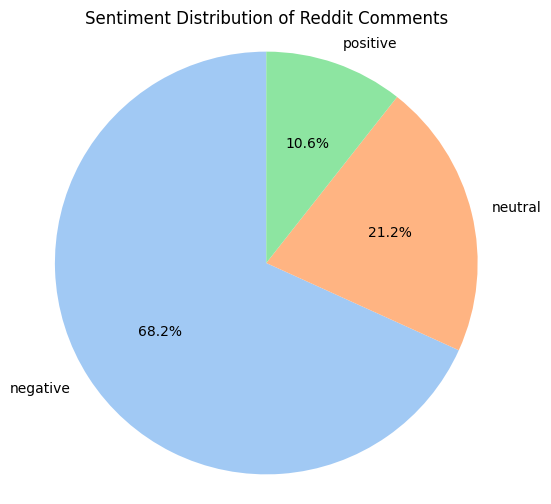

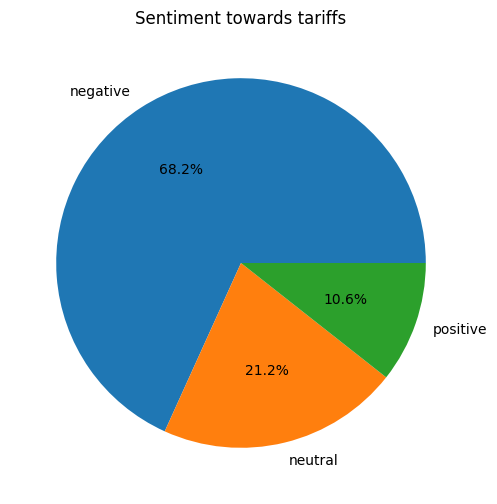

In [ ]:
# prompt: visualize the above code

import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset with ABSA results (this is missing in your original code)
df = pd.read_csv("reddit_comments_absa.csv")

# Bar plot for sentiment distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment_tariffs', data=df, palette="viridis")  # Corrected column name
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.title("Sentiment Distribution of Reddit Comments")
plt.show()


# Pie chart for sentiment distribution
sentiment_counts = df['sentiment_tariffs'].value_counts()  # Corrected column name
plt.figure(figsize=(6, 6))
plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
plt.title("Sentiment Distribution of Reddit Comments")
plt.axis('equal')
plt.show()






# Example visualization for aspect-based sentiment analysis (ABSA)
# Replace with your actual aspect data
# Example:
aspects = ["tariffs"]
for aspect in aspects:
    aspect_sentiment_counts = df[f"sentiment_{aspect}"].value_counts()
    plt.figure(figsize=(6, 6))
    plt.pie(aspect_sentiment_counts, labels=aspect_sentiment_counts.index, autopct='%1.1f%%')
    plt.title(f"Sentiment towards {aspect}")
    plt.show()
